In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
import cv2
from scipy.signal import convolve2d

In [2]:
# Define activation functions
def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

def elu(x, alpha=1.0):
    return np.where(x >= 0, x, alpha * (np.exp(x) - 1))

def gelu(x):
    return 0.5 * x * (1 + erf(x / np.sqrt(2)))

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

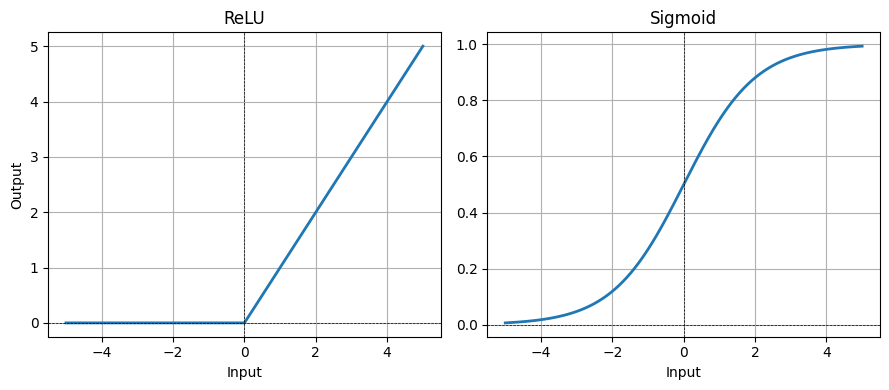

In [3]:
# Input range
x = np.linspace(-5, 5, 1000)

# Compute activations
y_relu = relu(x)
y_leaky = leaky_relu(x)
y_elu = elu(x)
y_gelu = gelu(x)
y_sigmoid = sigmoid(x)

# Prepare 2x2 subplot grid
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes = axes.flatten()

# List of activations to plot
activations = [
    ('ReLU', y_relu),
    ('Sigmoid', y_sigmoid)
]

axes[0].set_ylabel("Output")
for ax, (name, y) in zip(axes, activations):
    ax.plot(x, y, label=name, linewidth=2)
    ax.set_title(name)
    ax.set_xlabel("Input")
    
    ax.grid(True)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='black', linewidth=0.5, linestyle='--')
    # ax.legend(loc='lower right')

plt.tight_layout()
fig_name = "activations_relu_sigmoid"
plt.savefig(f"temp/{fig_name}.jpg", dpi=500, bbox_inches='tight', pad_inches=0)
plt.savefig(f"temp/{fig_name}.svg", format="svg", bbox_inches="tight")
plt.show()

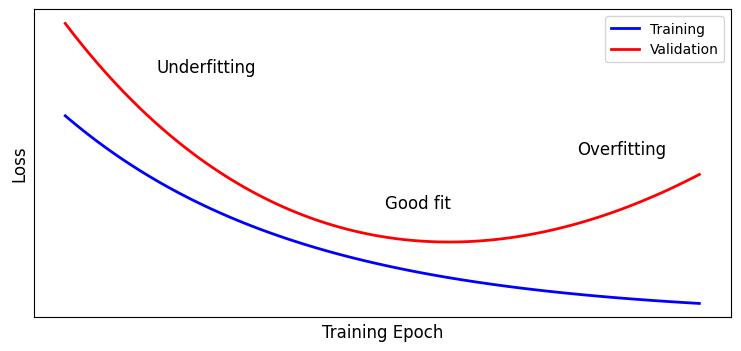

In [4]:
# X-axis: Tree Depth
x = np.linspace(1, 10, 100)

# Example curves
training = np.exp(-0.3 * x) + 0.1
validation = np.exp(-0.3 * x) + 0.2 + 0.15 * (x - 5)**2 / 10


# Create the plot
plt.figure(figsize=(9, 4))

# Plot lines
plt.plot(x, training, color='blue', linewidth=2, label='Training')
plt.plot(x, validation, color='red', linewidth=2, label='Validation')

# Axes labels
plt.xlabel("Training Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)

# Clean up plot (no grid, no legend)
plt.xticks([])
plt.yticks([])
plt.legend()

# Region labels
plt.text(3, 1.0, "Underfitting", fontsize=12, ha='center')
plt.text(6.0, 0.5, "Good fit", fontsize=12, ha='center')
plt.text(8.9, 0.7, "Overfitting", fontsize=12, ha='center')
fig_name = "nicefit_schema"
plt.savefig(f"temp/{fig_name}.jpg", dpi=500, bbox_inches='tight', pad_inches=0)
plt.savefig(f"temp/{fig_name}.svg", format="svg", bbox_inches="tight")
plt.show()

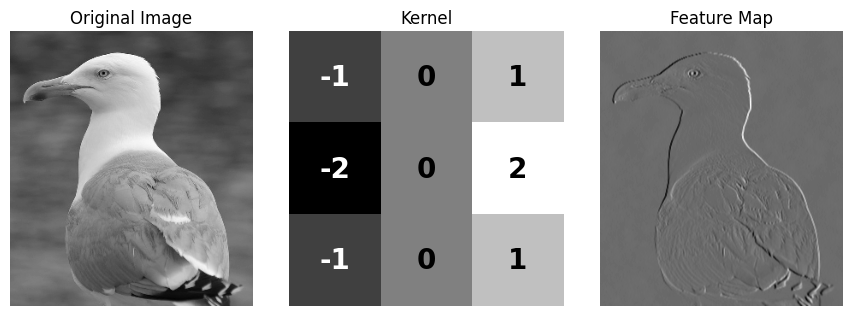

In [5]:
# Load grayscale image
img = cv2.imread('data/images/gull.jpg', cv2.IMREAD_GRAYSCALE)

# Normalize image for visualization
img = img[::2,::2].astype(np.float32) / 255.0

# Define first 3x3 kernel (e.g., Sobel X)
kernel1 = np.array([[ -1, 0, 1],
                    [ -2, 0, 2],
                    [ -1, 0, 1]])

# Apply first convolution
feature_map1 = convolve2d(img, kernel1, mode='same', boundary='symm')

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))

# Show original image
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

# Show first kernel as image
axes[1].imshow(kernel1, cmap='gray')
axes[1].set_title("Kernel")
axes[1].axis('off')

axes[1].imshow(kernel1, cmap='gray')
axes[1].set_title("Kernel")
axes[1].axis('off')

for i in range(kernel1.shape[0]):
    for j in range(kernel1.shape[1]):
        axes[1].text(
            j, i,
            f"{kernel1[i, j]:.0f}",
            ha="center",
            va="center",
            color="white" if kernel1[i, j] < 0 else "black",
            fontsize=20,
            fontweight="bold"
        )


# Show feature map after first filter
axes[2].imshow(feature_map1, cmap='gray')
axes[2].set_title("Feature Map")
axes[2].axis('off')

plt.tight_layout()
fig_name = "convolution_example"
plt.savefig(f"temp/{fig_name}.jpg", dpi=500, bbox_inches='tight', pad_inches=0)
plt.savefig(f"temp/{fig_name}.svg", format="svg", bbox_inches="tight")
plt.show()